In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import sys
sys.path.insert(0, "/Users/fabian/JuelichRepo_qecsim")  # the ASCII symlink you created


In [74]:
import stim
import numpy as np
import pymatching

from qecsim.surface_code_rotated.circuit import rotated_surface_code

In [79]:
def building_ptm(*,
                 circuit_0_z: stim.Circuit, circuit_1_z: stim.Circuit, 
                 circuit_0_x: stim.Circuit, circuit_1_x: stim.Circuit, 
                 circuit_p_x: stim.Circuit, circuit_m_x: stim.Circuit, 
                 circuit_p_z: stim.Circuit, circuit_m_z: stim.Circuit,
                 circuit_pi_y: stim.Circuit, circuit_mi_y: stim.Circuit,
                 circuit_0_y: stim.Circuit, circuit_1_y: stim.Circuit,
                 circuit_p_y: stim.Circuit, circuit_m_y: stim.Circuit,
                 rec_pos_log_x : list, rec_pos_log_z : list, 
                 rec_pos_log_y01 : list, rec_pos_log_ypm : list,
                 samples : int = 50) -> np.ndarray:

    """
    Building PTM by building each possible memory circuit and measurement combination
    -> + logical -> Measuring in x/z/y basis
    -> - logical -> Measuring in x/z/y basis
    -> 0 logical -> Measuring in x/z/y basis
    -> 1 logical -> Measuring in x/z/y basis
    -> +i logical -> Measuring in x/z/y basis

    What we do:
        * Determine the noise clean expectation of the measurement
        * Compute the noisy current observable status (xor noiseless initlial state by obs state)
        * Run QEC and check whether the noisy observable should be flipped or not
        * Flip the observable i.e. the clean expectation value
        * Build up PTM out of the expectaition values
     """

    #####################################
    # Builing Diagonal Entries of the PTM
    #####################################

    # Correct nosieless Measurements
    """
    Does this even make sense to define so specifically?
        -> We have only a pauli correction which could be done classically
        -> Initilizing in +x or -x or +z or -z makes no difference (Can be calssically correct, no?)
    """
    clean_meas_0_z = False
    clean_meas_1_z = True
    clean_meas_p_x = False
    clean_meas_m_x = True
    clean_meas_pi_y = False
    clean_meas_mi_y = True

    # Build a graphlike DEM and a matcher
    dem_0_z = circuit_0_z.detector_error_model(decompose_errors=True)
    m_0_z = pymatching.Matching.from_detector_error_model(dem_0_z)
    dem_1_z = circuit_1_z.detector_error_model(decompose_errors=True)
    m_1_z = pymatching.Matching.from_detector_error_model(dem_1_z)
    dem_p_x = circuit_p_x.detector_error_model(decompose_errors=True)
    m_p_x = pymatching.Matching.from_detector_error_model(dem_p_x)
    dem_m_x = circuit_m_x.detector_error_model(decompose_errors=True)
    m_m_x = pymatching.Matching.from_detector_error_model(dem_m_x)
    dem_pi_y = circuit_pi_y.detector_error_model(decompose_errors=True)
    m_pi_y = pymatching.Matching.from_detector_error_model(dem_pi_y)
    dem_mi_y = circuit_mi_y.detector_error_model(decompose_errors=True)
    m_mi_y = pymatching.Matching.from_detector_error_model(dem_mi_y)

    # Take m shots of detection events
    sampler_0_z = circuit_0_z.compile_detector_sampler()
    dets_0_z, obs_0_z = sampler_0_z.sample(samples, separate_observables=True)
    
    sampler_1_z = circuit_1_z.compile_detector_sampler()
    dets_1_z, obs_1_z = sampler_1_z.sample(samples, separate_observables=True)

    sampler_p_x = circuit_p_x.compile_detector_sampler()
    dets_p_x, obs_p_x = sampler_p_x.sample(samples, separate_observables=True)
    
    sampler_m_x = circuit_m_x.compile_detector_sampler()
    dets_m_x, obs_m_x = sampler_m_x.sample(samples, separate_observables=True)

    sampler_pi_y = circuit_pi_y.compile_detector_sampler()
    dets_pi_y, obs_pi_y = sampler_pi_y.sample(samples, separate_observables=True)
    
    sampler_mi_y = circuit_mi_y.compile_detector_sampler()
    dets_mi_y, obs_mi_y = sampler_mi_y.sample(samples, separate_observables=True)

    # Determine current noisy Operator states (i.e. xor obs from det sample with noiseless Measurement outcome)
    """
    THIS IS TOO MUCH WORK AND CAN BE SIMPLIFIED
    -> Just return freom each circuit the log rec tragets not only for the non determinstic emasurements
    -> Do analogue method than for the off diagonals
    -> This works but is more complicated and results in two methods beeing used in one function which can be mitigated
    """

    noisy_meas_0_z = []
    noisy_meas_1_z = []
    noisy_meas_p_x = []
    noisy_meas_m_x = []
    noisy_meas_pi_y = []
    noisy_meas_mi_y = []

    for curr_shot in range(samples):
        noisy_meas_0_z.append(obs_0_z[curr_shot,0] ^ clean_meas_0_z)
        noisy_meas_1_z.append(obs_1_z[curr_shot,0] ^ clean_meas_1_z)
        noisy_meas_p_x.append(obs_p_x[curr_shot,0] ^ clean_meas_p_x)
        noisy_meas_m_x.append(obs_m_x[curr_shot,0] ^ clean_meas_m_x)
        noisy_meas_pi_y.append(obs_pi_y[curr_shot,0] ^ clean_meas_pi_y)
        noisy_meas_mi_y.append(obs_mi_y[curr_shot,0] ^ clean_meas_mi_y)

    # Decode all sample round in one Batch decode
    pred_0_z = m_0_z.decode_batch(dets_0_z)
    pred_1_z = m_1_z.decode_batch(dets_1_z)
    pred_p_x = m_p_x.decode_batch(dets_p_x)
    pred_m_x = m_m_x.decode_batch(dets_m_x)
    pred_pi_y = m_pi_y.decode_batch(dets_pi_y)
    pred_mi_y = m_mi_y.decode_batch(dets_mi_y)

    # XOR flip with noiseless Measurement
    # -> Taking first entry for first logical observable
    final_meas_0_z = []
    final_meas_1_z = []
    final_meas_p_x = []
    final_meas_m_x = []
    final_meas_pi_y = []
    final_meas_mi_y = []

    for curr_shot in range(samples):
        final_meas_0_z.append( 1 - 2 * (pred_0_z[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_0_z[curr_shot])))
        final_meas_1_z.append( 1 - 2 * (pred_1_z[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_1_z[curr_shot])))
        final_meas_p_x.append( 1 - 2 * (pred_p_x[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_p_x[curr_shot])))
        final_meas_m_x.append( 1 - 2 * (pred_m_x[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_m_x[curr_shot])))
        final_meas_pi_y.append( 1 - 2 * (pred_pi_y[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_pi_y[curr_shot])))
        final_meas_mi_y.append( 1 - 2 * (pred_mi_y[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_mi_y[curr_shot])))

    # Take the Average of each of them
    mu_z_pz = np.average(final_meas_0_z)
    mu_z_mz = np.average(final_meas_1_z)
    mu_x_px = np.average(final_meas_p_x)
    mu_x_mx = np.average(final_meas_m_x)
    mu_y_py = np.average(final_meas_pi_y)
    mu_y_my = np.average(final_meas_mi_y)

    # Calc PTM entries
    r_zz = 1/2 * (mu_z_pz - mu_z_mz)
    r_xx = 1/2 * (mu_x_px - mu_x_mx)
    r_yy = 1/2 * (mu_y_py - mu_y_my)

    ######################################
    # Building Off-Diagonals of the Matrix
    ######################################

    """
    For the Off-Diagonals we can't directly use the DEM as we need the raw measurements to infer what logical state we have

    -> We use compile sampler to infer the logical state
    -> Convert into a dem to run the matching
    """

    # Build the normal measurement smaples and sample n shots
    smpl_0_x = circuit_0_x.compile_sampler()
    rstls_smpls_0_x = smpl_0_x.sample(shots = samples)
    smpl_0_y = circuit_0_y.compile_sampler()
    rstls_smpls_0_y = smpl_0_y.sample(shots = samples)
    smpl_1_x = circuit_1_x.compile_sampler()
    rstls_smpls_1_x = smpl_1_x.sample(shots = samples)
    smpl_1_y = circuit_1_y.compile_sampler()
    rstls_smpls_1_y = smpl_1_y.sample(shots = samples)
    smpl_p_z = circuit_p_z.compile_sampler()
    smpl_p_y = circuit_p_y.compile_sampler()
    rstls_smpls_p_y = smpl_p_y.sample(shots = samples)
    smpl_m_y = circuit_m_y.compile_sampler()
    rstls_smpls_m_y = smpl_m_y.sample(shots = samples)
    rstls_smpls_p_z = smpl_p_z.sample(shots = samples)
    smpl_m_z = circuit_m_z.compile_sampler()
    rstls_smpls_m_z = smpl_m_z.sample(shots = samples)


    # Getting the individual logical states after measurement
    log_state_0_x = []
    log_state_0_y = []
    log_state_1_x = []
    log_state_1_y = []
    log_state_p_y = []
    log_state_m_y = []
    log_state_p_z = []
    log_state_m_z = []

    for curr_shot in range(samples):

        measurement_res_0_x = -99
        measurement_res_1_x = -99
        measurement_res_p_z = -99
        measurement_res_m_z = -99
        measurement_res_0_y = -99
        measurement_res_1_y = -99
        measurement_res_p_y = -99
        measurement_res_m_y = -99

        # Do the first loop for all x basis measurements
        for current_tar_rec in rec_pos_log_x:
            
            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_0_x == -99:
                measurement_res_0_x = rstls_smpls_0_x[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_0_x ^= rstls_smpls_0_x[curr_shot, current_tar_rec]

            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_1_x == -99:
                measurement_res_1_x = rstls_smpls_1_x[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_1_x ^= rstls_smpls_1_x[curr_shot, current_tar_rec]

        # Do the same for z
        for current_tar_rec in rec_pos_log_z:
            
            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_p_z == -99:
                measurement_res_p_z = rstls_smpls_p_z[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_p_z ^= rstls_smpls_p_z[curr_shot, current_tar_rec]

            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_m_z == -99:
                measurement_res_m_z = rstls_smpls_m_z[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_m_z ^= rstls_smpls_m_z[curr_shot, current_tar_rec]

        for current_tar_rec in rec_pos_log_y01:
            if measurement_res_0_y == -99:
                measurement_res_0_y = rstls_smpls_0_y[curr_shot, current_tar_rec]
            else:
                measurement_res_0_y ^= rstls_smpls_0_y[curr_shot, current_tar_rec]

            if measurement_res_1_y == -99:
                measurement_res_1_y = rstls_smpls_1_y[curr_shot, current_tar_rec]

            else:
                measurement_res_1_y ^= rstls_smpls_1_y[curr_shot, current_tar_rec]

        for current_tar_rec in rec_pos_log_ypm:
            if measurement_res_p_y == -99:
                measurement_res_p_y = rstls_smpls_p_y[curr_shot, current_tar_rec]
            else:
                measurement_res_p_y ^= rstls_smpls_p_y[curr_shot, current_tar_rec]

            if measurement_res_m_y == -99:
                measurement_res_m_y = rstls_smpls_m_y[curr_shot, current_tar_rec]
            else:
                measurement_res_m_y ^= rstls_smpls_m_y[curr_shot, current_tar_rec]

        # Appending the current measurements to the list
        log_state_0_x.append(measurement_res_0_x)
        log_state_1_x.append(measurement_res_1_x)
        log_state_p_z.append(measurement_res_p_z)
        log_state_m_z.append(measurement_res_m_z)
        log_state_0_y.append(measurement_res_0_y)
        log_state_1_y.append(measurement_res_1_y)
        log_state_p_y.append(measurement_res_p_y)
        log_state_m_y.append(measurement_res_m_y)

    # Build a graphlike DEM and a matcher
    dem_0_x = circuit_0_x.detector_error_model(decompose_errors=True)
    m_0_x = pymatching.Matching.from_detector_error_model(dem_0_x)

    dem_1_x = circuit_1_x.detector_error_model(decompose_errors=True)
    m_1_x = pymatching.Matching.from_detector_error_model(dem_1_x)

    dem_p_z = circuit_p_z.detector_error_model(decompose_errors=True)
    m_p_z = pymatching.Matching.from_detector_error_model(dem_p_z)

    dem_m_z = circuit_m_z.detector_error_model(decompose_errors=True)
    m_m_z = pymatching.Matching.from_detector_error_model(dem_m_z)

    dem_0_y = circuit_0_y.detector_error_model(decompose_errors=True)
    m_0_y   = pymatching.Matching.from_detector_error_model(dem_0_y)

    dem_1_y = circuit_1_y.detector_error_model(decompose_errors=True)
    m_1_y   = pymatching.Matching.from_detector_error_model(dem_1_y)

    dem_p_y = circuit_p_y.detector_error_model(decompose_errors=True)
    m_p_y   = pymatching.Matching.from_detector_error_model(dem_p_y)

    dem_m_y = circuit_m_y.detector_error_model(decompose_errors=True)
    m_m_y   = pymatching.Matching.from_detector_error_model(dem_m_y)

    # Converting the measurement sample into DEM sample and continue as usual with decoding
    cvrtr_0_x = circuit_0_x.compile_m2d_converter()
    dets_ops_0_x = cvrtr_0_x.convert(measurements = rstls_smpls_0_x, append_observables=True)
    num_dets = dem_0_x.num_detectors
    num_obs  = dem_0_x.num_observables
    dets_0_x = dets_ops_0_x[:, :num_dets]
    obs_0_x  = dets_ops_0_x[:, num_dets:num_dets+num_obs]


    cvrtr_1_x = circuit_1_x.compile_m2d_converter()
    dets_ops_1_x = cvrtr_1_x.convert(measurements = rstls_smpls_1_x, append_observables=True)
    num_dets = dem_1_x.num_detectors
    num_obs  = dem_1_x.num_observables
    dets_1_x = dets_ops_1_x[:, :num_dets]
    obs_1_x  = dets_ops_1_x[:, num_dets:num_dets+num_obs]


    cvrtr_p_z = circuit_p_z.compile_m2d_converter()
    dets_ops_p_z = cvrtr_p_z.convert(measurements = rstls_smpls_p_z, append_observables=True)
    num_dets = dem_p_z.num_detectors
    num_obs  = dem_p_z.num_observables
    dets_p_z = dets_ops_p_z[:, :num_dets]
    obs_p_z  = dets_ops_p_z[:, num_dets:num_dets+num_obs]


    cvrtr_m_z = circuit_m_z.compile_m2d_converter()
    dets_ops_m_z = cvrtr_m_z.convert(measurements = rstls_smpls_m_z, append_observables=True)
    num_dets = dem_m_z.num_detectors
    num_obs  = dem_m_z.num_observables
    dets_m_z = dets_ops_m_z[:, :num_dets]
    obs_m_z  = dets_ops_m_z[:, num_dets:num_dets+num_obs]

    cvrtr_0_y = circuit_0_y.compile_m2d_converter()
    dets_ops_0_y = cvrtr_0_y.convert(measurements=rstls_smpls_0_y, append_observables=True)
    num_dets = dem_0_y.num_detectors
    num_obs  = dem_0_y.num_observables
    dets_0_y = dets_ops_0_y[:, :num_dets]
    obs_0_y  = dets_ops_0_y[:, num_dets:num_dets+num_obs]

    cvrtr_1_y = circuit_1_y.compile_m2d_converter()
    dets_ops_1_y = cvrtr_1_y.convert(measurements=rstls_smpls_1_y, append_observables=True)
    num_dets = dem_1_y.num_detectors
    num_obs  = dem_1_y.num_observables
    dets_1_y = dets_ops_1_y[:, :num_dets]
    obs_1_y  = dets_ops_1_y[:, num_dets:num_dets+num_obs]

    cvrtr_p_y = circuit_p_y.compile_m2d_converter()
    dets_ops_p_y = cvrtr_p_y.convert(measurements=rstls_smpls_p_y, append_observables=True)
    num_dets = dem_p_y.num_detectors
    num_obs  = dem_p_y.num_observables
    dets_p_y = dets_ops_p_y[:, :num_dets]
    obs_p_y  = dets_ops_p_y[:, num_dets:num_dets+num_obs]

    cvrtr_m_y = circuit_m_y.compile_m2d_converter()
    dets_ops_m_y = cvrtr_m_y.convert(measurements=rstls_smpls_m_y, append_observables=True)
    num_dets = dem_m_y.num_detectors
    num_obs  = dem_m_y.num_observables
    dets_m_y = dets_ops_m_y[:, :num_dets]
    obs_m_y  = dets_ops_m_y[:, num_dets:num_dets+num_obs]


    # Decode all sample round in one Batch decode
    pred_0_x = m_0_x.decode_batch(dets_0_x)
    pred_1_x = m_1_x.decode_batch(dets_1_x)

    pred_p_z = m_p_z.decode_batch(dets_p_z)
    pred_m_z = m_m_z.decode_batch(dets_m_z)

    pred_0_y = m_0_y.decode_batch(dets_0_y)
    pred_1_y = m_1_y.decode_batch(dets_1_y)

    pred_p_y = m_p_y.decode_batch(dets_p_y)
    pred_m_y = m_m_y.decode_batch(dets_m_y)


    # Init final state List after EC
    final_meas_0_x : list = []
    final_meas_1_x : list = []

    final_meas_p_z : list = []
    final_meas_m_z : list = []

    final_meas_0_y: list = []
    final_meas_1_y: list = []

    final_meas_p_y: list = []
    final_meas_m_y: list = []

    # XOR flip with noiseless Measurement (looping over all samples and compoaring to the current logical outcome in the list)
    # -> Taking first entry for first logical observable
    for current_sample in range(samples):
        curr_meas_0_x = 1 - 2 * (pred_0_x[current_sample,0].astype(np.int8) ^ np.int8(log_state_0_x[current_sample]))
        curr_meas_1_x = 1 - 2 * (pred_1_x[current_sample,0].astype(np.int8) ^ np.int8(log_state_1_x[current_sample]))

        curr_meas_p_z = 1 - 2 * (pred_p_z[current_sample,0].astype(np.int8) ^ np.int8(log_state_p_z[current_sample]))
        curr_meas_m_z = 1 - 2 * (pred_m_z[current_sample,0].astype(np.int8) ^ np.int8(log_state_m_z[current_sample]))

        curr_meas_0_y = 1 - 2 * (pred_0_y[current_sample, 0].astype(np.int8) ^ np.int8(log_state_0_y[current_sample]))
        curr_meas_1_y = 1 - 2 * (pred_1_y[current_sample, 0].astype(np.int8) ^ np.int8(log_state_1_y[current_sample]))

        curr_meas_p_y = 1 - 2 * (pred_p_y[current_sample, 0].astype(np.int8) ^ np.int8(log_state_p_y[current_sample]))
        curr_meas_m_y = 1 - 2 * (pred_m_y[current_sample, 0].astype(np.int8) ^ np.int8(log_state_m_y[current_sample]))


        #Adding final XORed measurement into the list
        final_meas_0_x.append(curr_meas_0_x)
        final_meas_1_x.append(curr_meas_1_x)

        final_meas_p_z.append(curr_meas_p_z)
        final_meas_m_z.append(curr_meas_m_z)

        final_meas_0_y.append(curr_meas_0_y)
        final_meas_1_y.append(curr_meas_1_y)

        final_meas_p_y.append(curr_meas_p_y)
        final_meas_m_y.append(curr_meas_m_y)

    # Take the Average of each of them
    mu_x_pz = np.average(final_meas_0_x)
    mu_x_mz = np.average(final_meas_1_x)
    mu_z_px = np.average(final_meas_p_z)
    mu_z_mx = np.average(final_meas_m_z)
    mu_y_pz = np.average(final_meas_0_y)
    mu_y_mz = np.average(final_meas_1_y)
    mu_y_px = np.average(final_meas_p_y)
    mu_y_mx = np.average(final_meas_m_y)

    # Calc PTM entries
    r_zx = 1/2 * (mu_z_px - mu_z_mx)
    r_xz = 1/2 * (mu_x_pz - mu_x_mz)
    r_xy = 1/2 * (mu_y_px - mu_y_mx)
    r_zy = 1/2 * (mu_y_pz - mu_y_mz)

    # Create PTM Matrix
    ptm = [
        [r_xx, r_xy, r_xz], 
        [0.0, r_yy , 0.0], 
        [r_zx, r_zy , r_zz]]

    return(np.array(ptm))

In [80]:
noise = 0.007
distance = 3

c_0_z = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Z", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_x = rotated_surface_code(distance = distance, rounds = distance, log_obs = "X", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_y = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Y", state_init = "+i", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_0_x, rec_pos_log_x = rotated_surface_code(distance = distance, rounds = distance, log_obs = "X", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_z, rec_pos_log_z = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Z", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_0_y, rec_pos_log_y0 = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Y", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_y, rec_pos_log_yp = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Y", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)

In [83]:
building_ptm(circuit_0_x = c_0_x, circuit_1_x = c_0_x, circuit_0_z = c_0_z, circuit_1_z = c_0_z,
            circuit_p_x = c_p_x, circuit_m_x = c_p_x, circuit_p_z = c_p_z, circuit_m_z = c_p_z, 
            circuit_mi_y = c_y, circuit_pi_y= c_y, circuit_0_y= c_0_y, circuit_1_y= c_0_y, 
            circuit_p_y= c_p_y, circuit_m_y= c_p_y,
            rec_pos_log_y01= rec_pos_log_y0, rec_pos_log_ypm= rec_pos_log_yp,
            rec_pos_log_x = rec_pos_log_x, rec_pos_log_z = rec_pos_log_z, samples = 10_000)

array([[ 0.9489,  0.006 , -0.0013],
       [ 0.    ,  0.6794,  0.    ],
       [ 0.0031, -0.0054,  0.9499]])

In [7]:
[2 + i + 2j + 1j * i for i in range(0,distance * 2 + 2, 2)]

[(2+2j), (4+4j), (6+6j), (8+8j)]

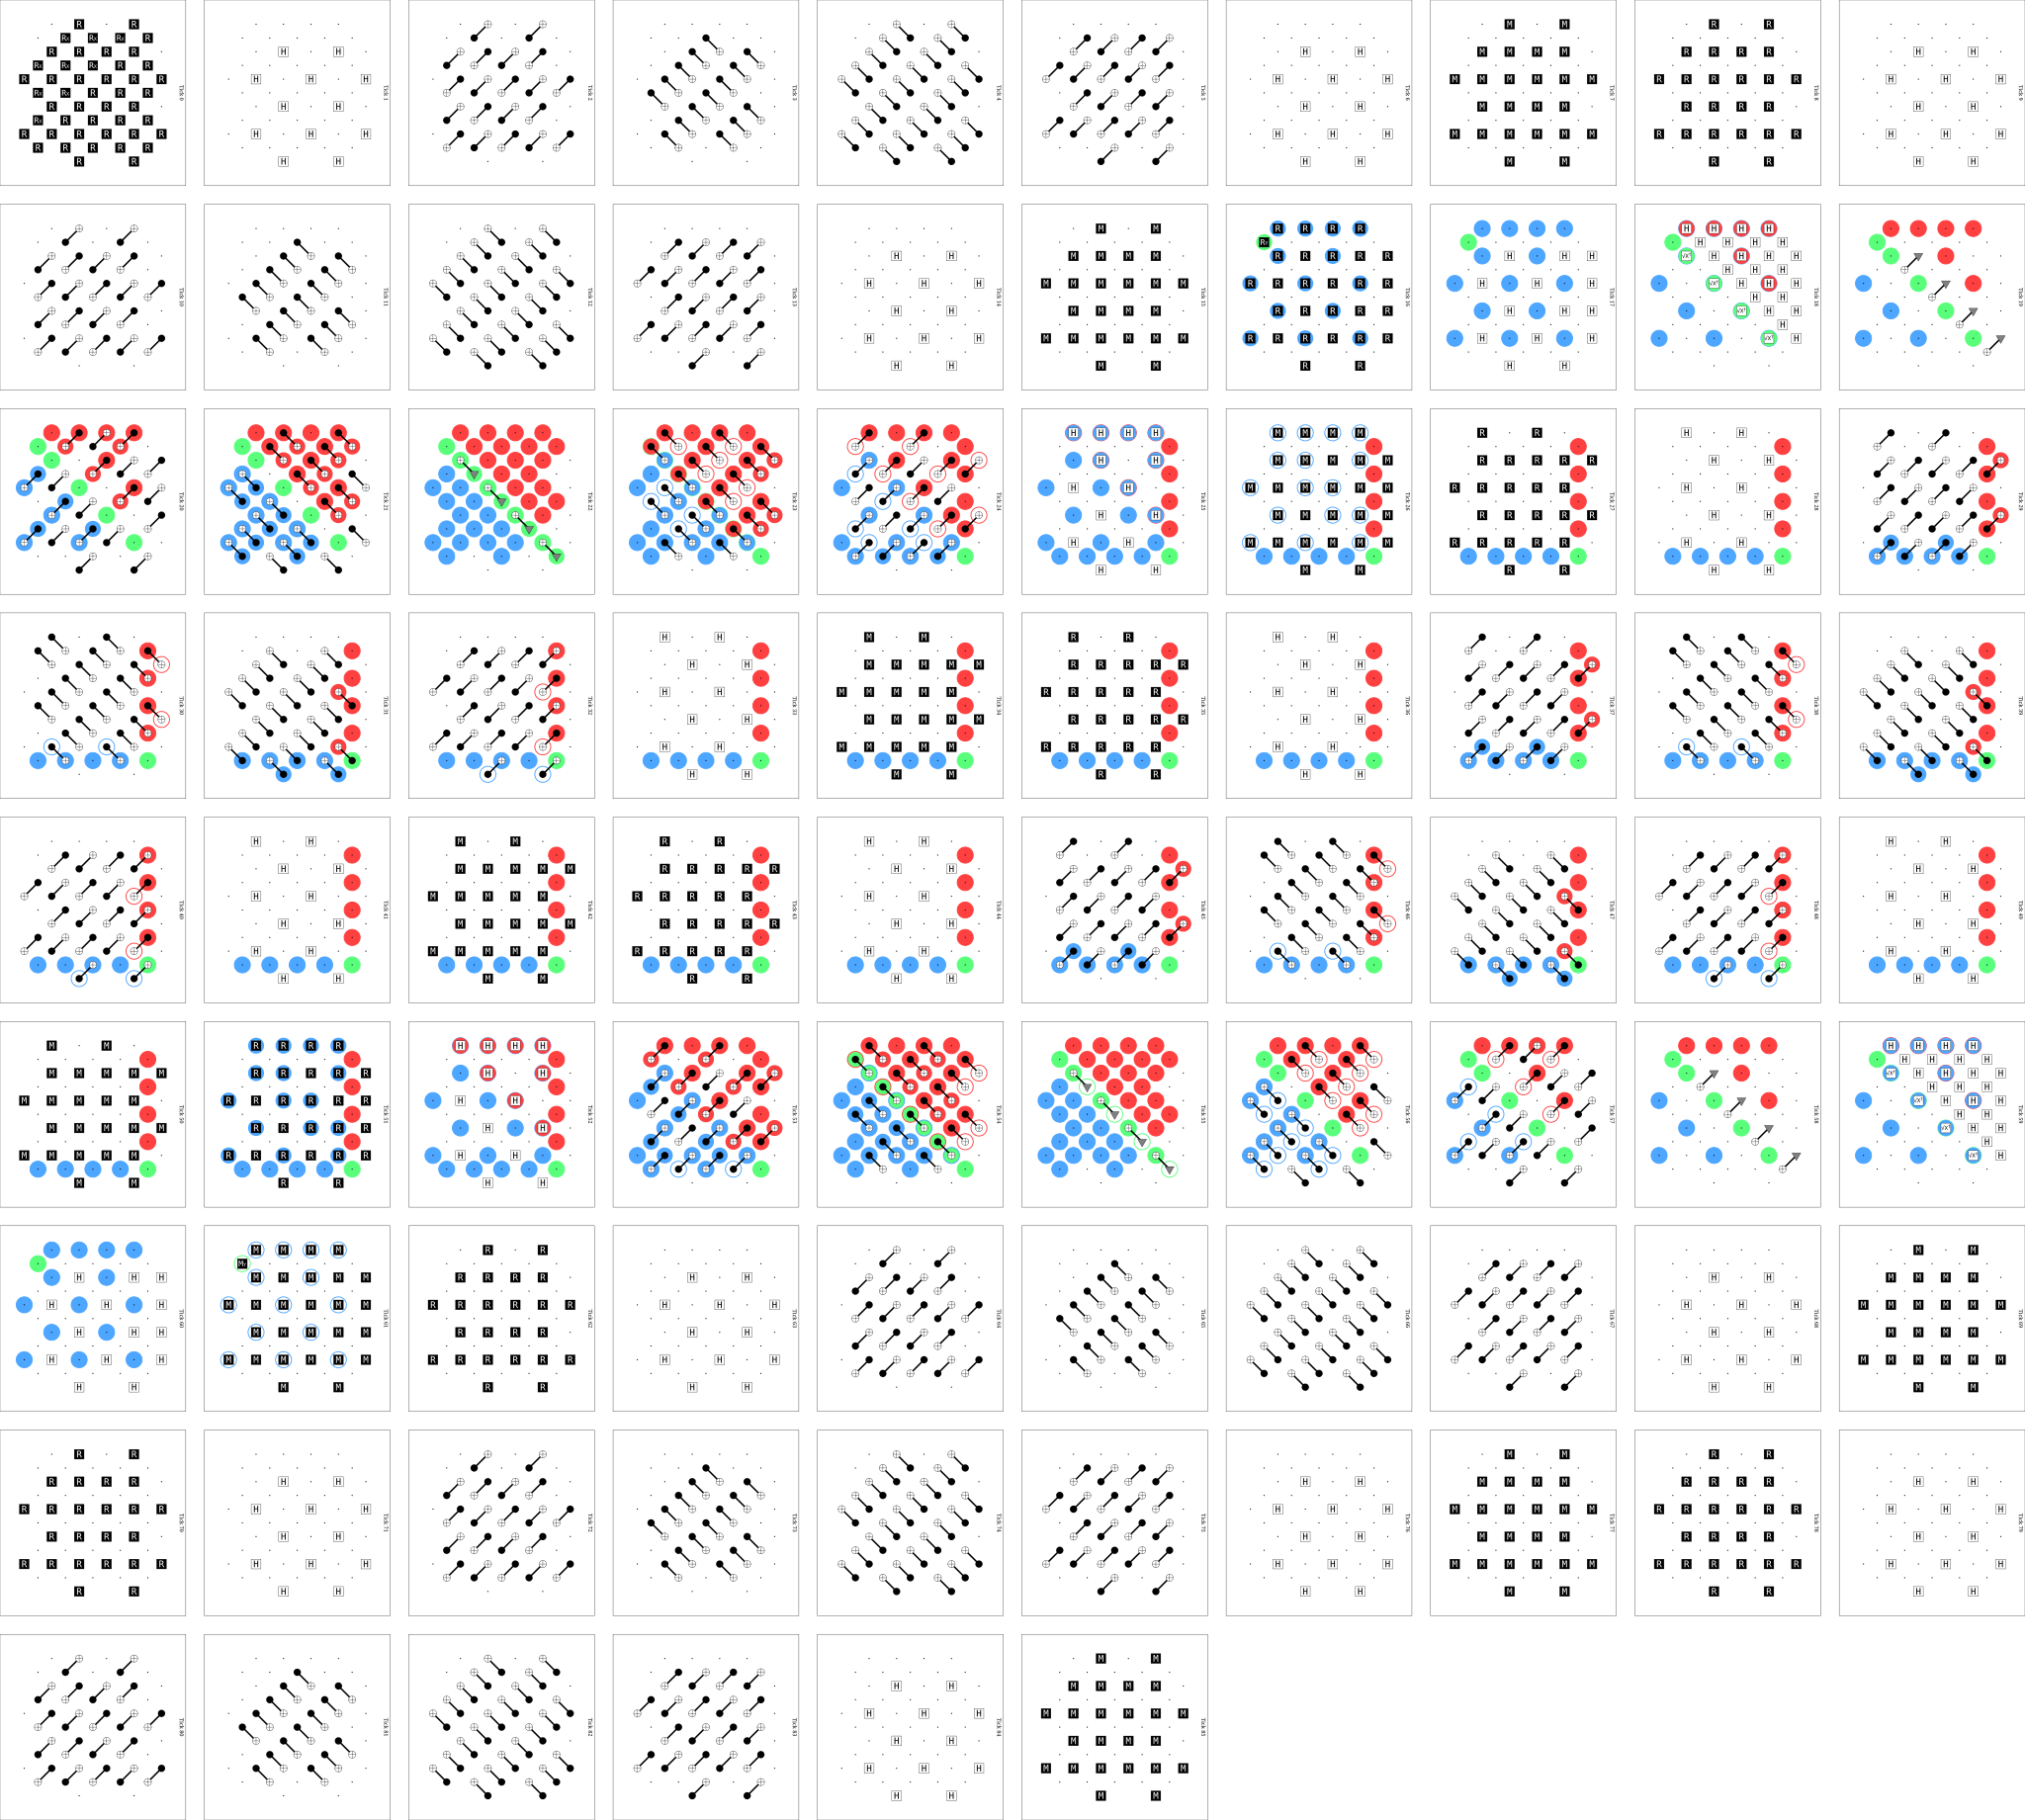

In [85]:
test = rotated_surface_code(distance = 5, rounds = 3, log_obs = "Y", state_init = "+i")

test.diagram("detslice-with-ops-svg", filter_coords = "L0")

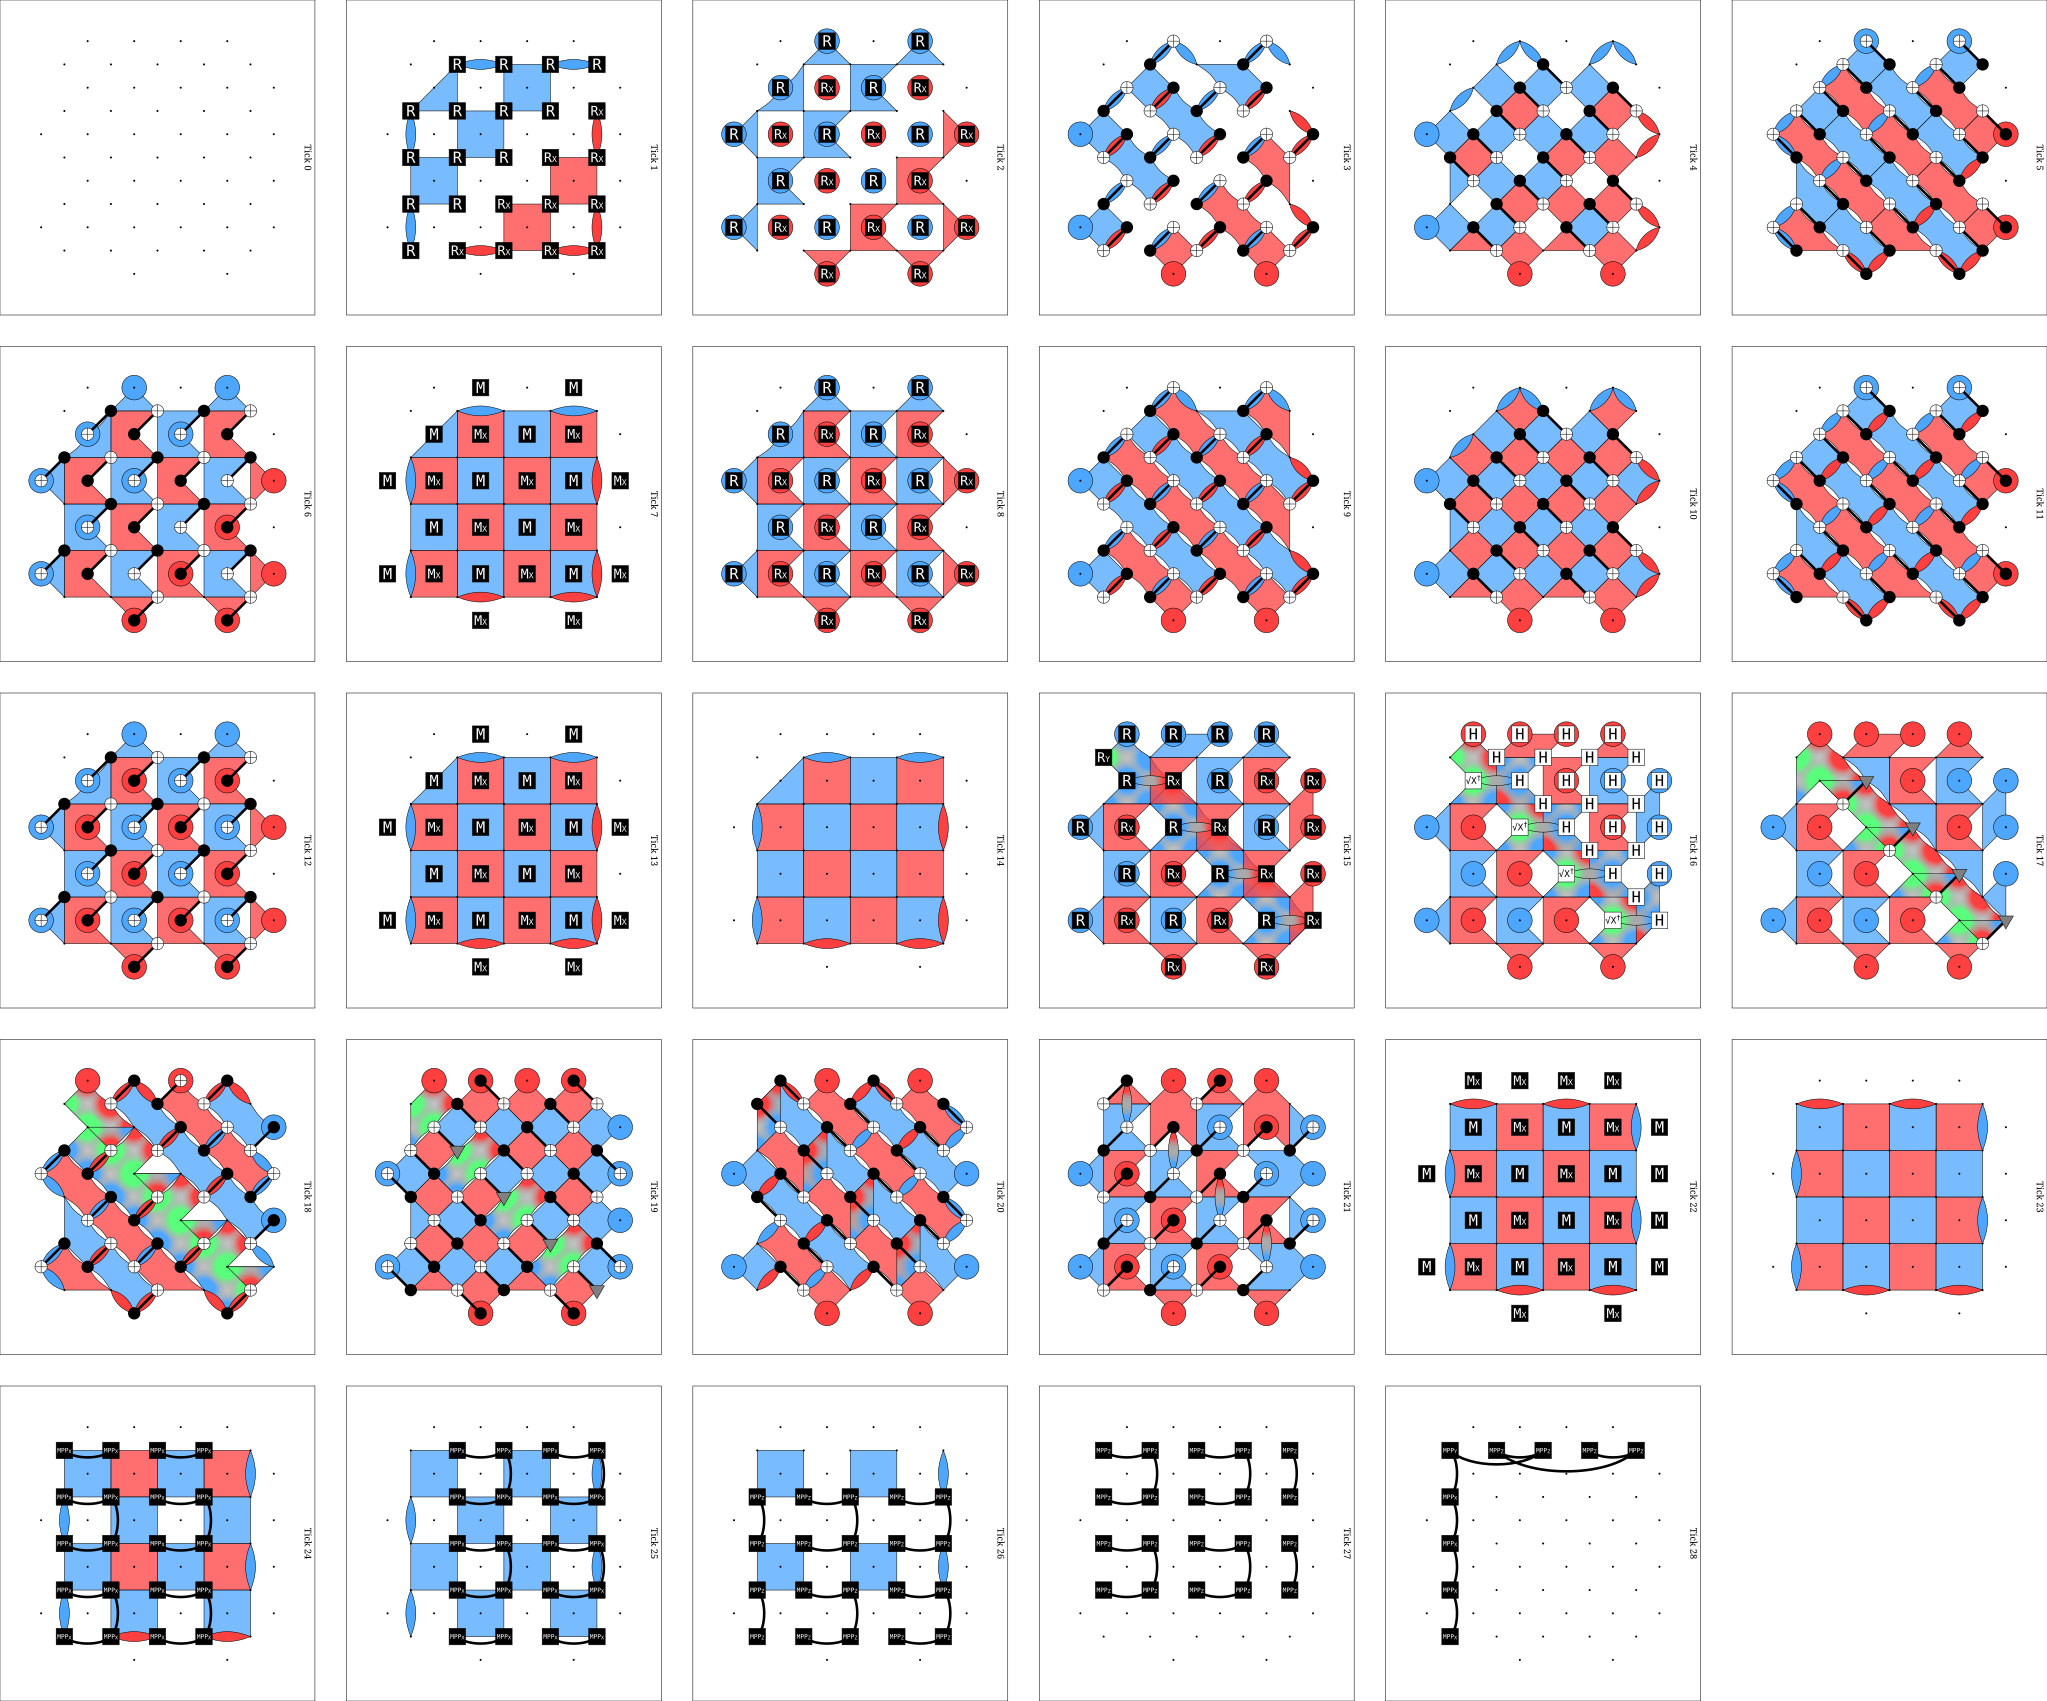

In [ ]:
stim.Circuit("""QUBIT_COORDS(0, 2) 0
QUBIT_COORDS(0, 4) 1
QUBIT_COORDS(0.5, 0.5) 2
QUBIT_COORDS(0.5, 1.5) 3
QUBIT_COORDS(0.5, 2.5) 4
QUBIT_COORDS(0.5, 3.5) 5
QUBIT_COORDS(0.5, 4.5) 6
QUBIT_COORDS(1, 0) 7
QUBIT_COORDS(1, 1) 8
QUBIT_COORDS(1, 2) 9
QUBIT_COORDS(1, 3) 10
QUBIT_COORDS(1, 4) 11
QUBIT_COORDS(1.5, 0.5) 12
QUBIT_COORDS(1.5, 1.5) 13
QUBIT_COORDS(1.5, 2.5) 14
QUBIT_COORDS(1.5, 3.5) 15
QUBIT_COORDS(1.5, 4.5) 16
QUBIT_COORDS(2, 0) 17
QUBIT_COORDS(2, 1) 18
QUBIT_COORDS(2, 2) 19
QUBIT_COORDS(2, 3) 20
QUBIT_COORDS(2, 4) 21
QUBIT_COORDS(2, 5) 22
QUBIT_COORDS(2.5, 0.5) 23
QUBIT_COORDS(2.5, 1.5) 24
QUBIT_COORDS(2.5, 2.5) 25
QUBIT_COORDS(2.5, 3.5) 26
QUBIT_COORDS(2.5, 4.5) 27
QUBIT_COORDS(3, 0) 28
QUBIT_COORDS(3, 1) 29
QUBIT_COORDS(3, 2) 30
QUBIT_COORDS(3, 3) 31
QUBIT_COORDS(3, 4) 32
QUBIT_COORDS(3.5, 0.5) 33
QUBIT_COORDS(3.5, 1.5) 34
QUBIT_COORDS(3.5, 2.5) 35
QUBIT_COORDS(3.5, 3.5) 36
QUBIT_COORDS(3.5, 4.5) 37
QUBIT_COORDS(4, 0) 38
QUBIT_COORDS(4, 1) 39
QUBIT_COORDS(4, 2) 40
QUBIT_COORDS(4, 3) 41
QUBIT_COORDS(4, 4) 42
QUBIT_COORDS(4, 5) 43
QUBIT_COORDS(4.5, 0.5) 44
QUBIT_COORDS(4.5, 1.5) 45
QUBIT_COORDS(4.5, 2.5) 46
QUBIT_COORDS(4.5, 3.5) 47
QUBIT_COORDS(4.5, 4.5) 48
QUBIT_COORDS(5, 1) 49
QUBIT_COORDS(5, 2) 50
QUBIT_COORDS(5, 3) 51
QUBIT_COORDS(5, 4) 52
#!pragma POLYGON(0,0,1,0.25) 12 13 3
#!pragma POLYGON(0,0,1,0.25) 4 14 15 5
#!pragma POLYGON(0,0,1,0.25) 13 24 25 14
#!pragma POLYGON(0,0,1,0.25) 15 26 27 16
#!pragma POLYGON(0,0,1,0.25) 23 33 34 24
#!pragma POLYGON(0,0,1,0.25) 25 35 36 26
#!pragma POLYGON(0,0,1,0.25) 34 45 46 35
#!pragma POLYGON(0,0,1,0.25) 36 47 48 37
#!pragma POLYGON(0,0,1,0.25) 3 4
#!pragma POLYGON(0,0,1,0.25) 5 6
#!pragma POLYGON(0,0,1,0.25) 23 12
#!pragma POLYGON(0,0,1,0.25) 44 33
#!pragma POLYGON(1,0,0,0.25) 3 13 14 4
#!pragma POLYGON(1,0,0,0.25) 5 15 16 6
#!pragma POLYGON(1,0,0,0.25) 12 23 24 13
#!pragma POLYGON(1,0,0,0.25) 14 25 26 15
#!pragma POLYGON(1,0,0,0.25) 24 34 35 25
#!pragma POLYGON(1,0,0,0.25) 26 36 37 27
#!pragma POLYGON(1,0,0,0.25) 33 44 45 34
#!pragma POLYGON(1,0,0,0.25) 35 46 47 36
#!pragma POLYGON(1,0,0,0.25) 27 16
#!pragma POLYGON(1,0,0,0.25) 48 37
#!pragma POLYGON(1,0,0,0.25) 47 48
#!pragma POLYGON(1,0,0,0.25) 45 46
TICK
R 25 15 14 13 24 34 44 33 23 12 3 4 5 6
RX 45 46 35 47 36 26 48 37 27 16
TICK
R 0 1 42 40 38 31 29 21 19 17 10 8
RX 52 50 43 41 39 32 30 22 20 18 11 9
TICK
CX 37 42 35 40 33 38 26 31 24 29 16 21 14 19 12 17 5 10 3 8 52 48 50 46 41 36 39 34 32 27 30 25 20 15 18 13 11 6 9 4
TICK
CX 41 47 39 45 32 37 30 35 20 26 18 24 11 16 9 14 36 42 34 40 25 31 23 29 15 21 13 19 4 10
TICK
CX 52 47 50 45 43 37 41 35 39 33 32 26 30 24 22 16 20 14 18 12 11 5 9 3 4 0 6 1 48 42 46 40 44 38 36 31 34 29 27 21 25 19 23 17 15 10 13 8
TICK
CX 43 48 41 46 39 44 32 36 30 34 22 27 20 25 18 23 11 15 9 13 3 0 5 1 47 42 45 40 35 31 33 29 26 21 24 19 14 10 12 8
TICK
M 1 0 42 40 38 31 29 21 19 17 10 8
MX 52 50 43 41 39 32 30 22 20 18 11 9
DETECTOR(0, 4, 0) rec[-24]
DETECTOR(0, 2, 0) rec[-23]
DETECTOR(4, 0, 0) rec[-20]
DETECTOR(3, 1, 0) rec[-18]
DETECTOR(2, 2, 0) rec[-16]
DETECTOR(2, 0, 0) rec[-15]
DETECTOR(1, 3, 0) rec[-14]
DETECTOR(1, 1, 0) rec[-13]
DETECTOR(5, 4, 0) rec[-12]
DETECTOR(5, 2, 0) rec[-11]
DETECTOR(4, 5, 0) rec[-10]
DETECTOR(4, 3, 0) rec[-9]
DETECTOR(3, 4, 0) rec[-7]
DETECTOR(2, 5, 0) rec[-5]
TICK
R 0 1 42 40 38 31 29 21 19 17 10 8
RX 52 50 43 41 39 32 30 22 20 18 11 9
TICK
CX 37 42 35 40 33 38 26 31 24 29 16 21 14 19 12 17 5 10 3 8 52 48 50 46 41 36 39 34 32 27 30 25 20 15 18 13 11 6 9 4
TICK
CX 41 47 39 45 32 37 30 35 20 26 18 24 11 16 9 14 36 42 34 40 25 31 23 29 15 21 13 19 4 10
TICK
CX 52 47 50 45 43 37 41 35 39 33 32 26 30 24 22 16 20 14 18 12 11 5 9 3 4 0 6 1 48 42 46 40 44 38 36 31 34 29 27 21 25 19 23 17 15 10 13 8
TICK
CX 43 48 41 46 39 44 32 36 30 34 22 27 20 25 18 23 11 15 9 13 3 0 5 1 47 42 45 40 35 31 33 29 26 21 24 19 14 10 12 8
TICK
M 1 0 42 40 38 31 29 21 19 17 10 8
MX 52 50 43 41 39 32 30 22 20 18 11 9
DETECTOR(0, 4, 1) rec[-24] rec[-48]
DETECTOR(0, 2, 1) rec[-23] rec[-47]
DETECTOR(4, 4, 1) rec[-22] rec[-46]
DETECTOR(4, 2, 1) rec[-21] rec[-45]
DETECTOR(4, 0, 1) rec[-20] rec[-44]
DETECTOR(3, 3, 1) rec[-19] rec[-43]
DETECTOR(3, 1, 1) rec[-18] rec[-42]
DETECTOR(2, 4, 1) rec[-17] rec[-41]
DETECTOR(2, 2, 1) rec[-16] rec[-40]
DETECTOR(2, 0, 1) rec[-15] rec[-39]
DETECTOR(1, 3, 1) rec[-14] rec[-38]
DETECTOR(1, 1, 1) rec[-13] rec[-37]
DETECTOR(5, 4, 1) rec[-12] rec[-36]
DETECTOR(5, 2, 1) rec[-11] rec[-35]
DETECTOR(4, 5, 1) rec[-10] rec[-34]
DETECTOR(4, 3, 1) rec[-9] rec[-33]
DETECTOR(4, 1, 1) rec[-8] rec[-32]
DETECTOR(3, 4, 1) rec[-7] rec[-31]
DETECTOR(3, 2, 1) rec[-6] rec[-30]
DETECTOR(2, 5, 1) rec[-5] rec[-29]
DETECTOR(2, 3, 1) rec[-4] rec[-28]
DETECTOR(2, 1, 1) rec[-3] rec[-27]
DETECTOR(1, 4, 1) rec[-2] rec[-26]
DETECTOR(1, 2, 1) rec[-1] rec[-25]
TICK
#!pragma POLYGON(0,0,1,0.25) 13 24 25 14
#!pragma POLYGON(0,0,1,0.25) 4 14 15 5
#!pragma POLYGON(0,0,1,0.25) 15 26 27 16
#!pragma POLYGON(0,0,1,0.25) 25 35 36 26
#!pragma POLYGON(0,0,1,0.25) 3 4
#!pragma POLYGON(0,0,1,0.25) 5 6
#!pragma POLYGON(0,0,1,0.25) 23 33 34 24
#!pragma POLYGON(0,0,1,0.25) 2 12 13 3
#!pragma POLYGON(0,0,1,0.25) 34 45 46 35
#!pragma POLYGON(0,0,1,0.25) 36 47 48 37
#!pragma POLYGON(0,0,1,0.25) 38
#!pragma POLYGON(0,0,1,0.25) 28
#!pragma POLYGON(0,0,1,0.25) 17
#!pragma POLYGON(0,0,1,0.25) 7
#!pragma POLYGON(0,0.5,0,1) 2 48
#!pragma POLYGON(1,0,0,0.25) 3 13 14 4
#!pragma POLYGON(1,0,0,0.25) 14 25 26 15
#!pragma POLYGON(1,0,0,0.25) 5 15 16 6
#!pragma POLYGON(1,0,0,0.25) 26 36 37 27
#!pragma POLYGON(1,0,0,0.25) 24 34 35 25
#!pragma POLYGON(1,0,0,0.25) 27 16
#!pragma POLYGON(1,0,0,0.25) 48 37
#!pragma POLYGON(1,0,0,0.25) 12 23 24 13
#!pragma POLYGON(1,0,0,0.25) 33 44 45 34
#!pragma POLYGON(1,0,0,0.25) 35 46 47 36
#!pragma POLYGON(1,0,0,0.25) 52
#!pragma POLYGON(1,0,0,0.25) 51
#!pragma POLYGON(1,0,0,0.25) 50
#!pragma POLYGON(1,0,0,0.25) 49
TICK
R 42 40 38 31 29 28 21 19 17 10 8 7 1 0
RX 52 51 50 49 43 41 39 32 30 22 20 18 11 9
RY 2
TICK
H 52 51 50 49 41 40 39 38 30 29 28 18 17 7 47 46 45 44 35 34 33 24 23 12
SQRT_X_DAG 42 31 19 8
TICK
XCY 48 52 36 41 25 30 13 18
TICK
CX 26 21 14 10 5 1 3 0 43 48 32 36 22 27 20 25 11 15 9 13 51 47 49 45 40 35 38 33 29 24 17 12 46 50 34 39 23 28
TICK
CX 27 21 15 10 6 1 4 0 43 37 32 26 22 16 20 14 11 5 9 3 40 46 38 44 29 34 17 23 47 52 45 50 35 41 33 39 24 30 12 18
XCY 42 48 31 36 19 25 8 13
TICK
CX 46 51 44 49 36 42 34 40 25 31 23 29 15 21 13 19 4 10 2 8 41 47 39 45 32 37 30 35 28 33 20 26 18 24 11 16 9 14 7 12
TICK
CX 47 51 45 49 37 42 35 40 26 31 24 29 16 21 14 19 5 10 3 8 41 36 39 34 32 27 30 25 28 23 20 15 18 13 11 6 9 4 7 2
TICK
M 52 51 50 49 42 40 31 29 21 19 10 8 1 0
MX 43 41 39 38 32 30 28 22 20 18 17 11 9 7
DETECTOR(5, 4, 2) rec[-28] rec[-40]
DETECTOR(4, 3, 2) rec[-27] rec[-37]
DETECTOR(5, 2, 2) rec[-26] rec[-39]
DETECTOR(4, 1, 2) rec[-25] rec[-36]
DETECTOR(3, 2, 2) rec[-23] rec[-34]
DETECTOR(2, 1, 2) rec[-21] rec[-31]
DETECTOR(2, 4, 2) rec[-20] rec[-45]
DETECTOR(1, 3, 2) rec[-18] rec[-42]
DETECTOR(0, 4, 2) rec[-16] rec[-52]
DETECTOR(0, 2, 2) rec[-15] rec[-51]
DETECTOR(4, 5, 2) rec[-14] rec[-38]
DETECTOR(4, 4, 2) rec[-13] rec[-24] rec[-50]
DETECTOR(4, 2, 2) rec[-12] rec[-49]
DETECTOR(4, 0, 2) rec[-11] rec[-48]
DETECTOR(3, 4, 2) rec[-10] rec[-35]
DETECTOR(3, 3, 2) rec[-9] rec[-22] rec[-47]
DETECTOR(3, 1, 2) rec[-8] rec[-46]
DETECTOR(2, 5, 2) rec[-7] rec[-33]
DETECTOR(2, 3, 2) rec[-6] rec[-32]
DETECTOR(2, 2, 2) rec[-5] rec[-19] rec[-44]
DETECTOR(2, 0, 2) rec[-4] rec[-43]
DETECTOR(1, 4, 2) rec[-3] rec[-30]
DETECTOR(1, 2, 2) rec[-2] rec[-29]
DETECTOR(1, 1, 2) rec[-1] rec[-17] rec[-41]
TICK
#!pragma POLYGON(0,0,1,0.25) 2 12 13 3
#!pragma POLYGON(0,0,1,0.25) 13 24 25 14
#!pragma POLYGON(0,0,1,0.25) 4 14 15 5
#!pragma POLYGON(0,0,1,0.25) 15 26 27 16
#!pragma POLYGON(0,0,1,0.25) 25 35 36 26
#!pragma POLYGON(0,0,1,0.25) 36 47 48 37
#!pragma POLYGON(0,0,1,0.25) 23 33 34 24
#!pragma POLYGON(0,0,1,0.25) 34 45 46 35
#!pragma POLYGON(0,0,1,0.25) 44 45
#!pragma POLYGON(0,0,1,0.25) 3 4
#!pragma POLYGON(0,0,1,0.25) 5 6
#!pragma POLYGON(0,0,1,0.25) 46 47
#!pragma POLYGON(1,0,0,0.25) 12 23 24 13
#!pragma POLYGON(1,0,0,0.25) 3 13 14 4
#!pragma POLYGON(1,0,0,0.25) 14 25 26 15
#!pragma POLYGON(1,0,0,0.25) 5 15 16 6
#!pragma POLYGON(1,0,0,0.25) 35 46 47 36
#!pragma POLYGON(1,0,0,0.25) 26 36 37 27
#!pragma POLYGON(1,0,0,0.25) 33 44 45 34
#!pragma POLYGON(1,0,0,0.25) 24 34 35 25
#!pragma POLYGON(1,0,0,0.25) 12 2
#!pragma POLYGON(1,0,0,0.25) 33 23
#!pragma POLYGON(1,0,0,0.25) 27 16
#!pragma POLYGON(1,0,0,0.25) 48 37
TICK
MPP X33*X23 X12*X2 X27*X37*X36*X26 X25*X35*X34*X24 X4*X14*X13*X3 X6*X16*X15*X5
DETECTOR(3, 0, 3) rec[-6] rec[-14]
DETECTOR(1, 0, 3) rec[-5] rec[-7]
DETECTOR(3, 4, 3) rec[-4] rec[-16]
DETECTOR(3, 2, 3) rec[-3] rec[-15]
DETECTOR(1, 2, 3) rec[-2] rec[-8]
DETECTOR(1, 4, 3) rec[-1] rec[-9]
TICK
MPP X48*X37 X27*X16 X36*X47*X46*X35 X34*X45*X44*X33 X13*X24*X23*X12 X15*X26*X25*X14
DETECTOR(4, 5, 4) rec[-6] rec[-26]
DETECTOR(2, 5, 4) rec[-5] rec[-19]
DETECTOR(4, 3, 4) rec[-4] rec[-25]
DETECTOR(4, 0, 4) rec[-3] rec[-23] rec[-24]
DETECTOR(2, 0, 4) rec[-2] rec[-16] rec[-17]
DETECTOR(2, 3, 4) rec[-1] rec[-18]
TICK
MPP Z6*Z5 Z4*Z3 Z35*Z46*Z45*Z34 Z37*Z48*Z47*Z36 Z16*Z27*Z26*Z15 Z14*Z25*Z24*Z13
DETECTOR(0, 4, 5) rec[-6] rec[-34]
DETECTOR(0, 2, 5) rec[-5] rec[-33]
DETECTOR(4, 2, 5) rec[-4] rec[-41] rec[-44]
DETECTOR(4, 4, 5) rec[-3] rec[-42] rec[-46]
DETECTOR(2, 4, 5) rec[-2] rec[-38]
DETECTOR(2, 2, 5) rec[-1] rec[-37]
TICK
MPP Z47*Z46 Z45*Z44 Z24*Z34*Z33*Z23 Z26*Z36*Z35*Z25 Z5*Z15*Z14*Z4 Z3*Z13*Z12*Z2
DETECTOR(5, 3, 6) rec[-6] rec[-51]
DETECTOR(5, 1, 6) rec[-5] rec[-49]
DETECTOR(3, 1, 6) rec[-4] rec[-45]
DETECTOR(3, 3, 6) rec[-3] rec[-46]
DETECTOR(1, 3, 6) rec[-2] rec[-42]
DETECTOR(1, 1, 6) rec[-1] rec[-41]
TICK
MPP X6*X5*X4*X3*Y2*Z23*Z12*Z44*Z33
OBSERVABLE_INCLUDE(0) rec[-1] rec[-54] rec[-55] rec[-56] rec[-57] rec[-58] rec[-59] rec[-60] rec[-61] rec[-62] rec[-63] rec[-64] rec[-65]


""").diagram("detslice-with-ops-svg", tick = range(0,40))

In [ ]:
circuit = stim.Circuit('''
            R 1 3
            CX 0 1 2 3
           CX 4 3 2 1
            M 1 3
        ''')
circuit.solve_flow_measurements([
        stim.Flow("1 -> Z0*Z2"),
        stim.Flow("1 -> Z2*Z4"),
        stim.Flow("Z0*Z2 -> 1"),
        ])

[[0], [1], [0]]